In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_parquet(r"final_df/train_df_preprocessed.parquet")
test_df = pd.read_parquet(r"final_df/test_df_preprocessed.parquet")

In [15]:
classes = train_df[' Label'].value_counts().to_list()
NUM_CLASSES = len(classes)
classes

[31786, 30000, 30000, 25605, 8234, 6350, 4718, 4637, 4399, 1206, 983, 360]

In [25]:
train_df.columns

Index(['Init_Win_bytes_forward', ' Init_Win_bytes_backward', ' Flow IAT Min',
       ' Fwd IAT Min', ' Flow Duration', ' Bwd IAT Min',
       'Total Length of Fwd Packets', 'Bwd Packet Length Max', 'Flow Bytes/s',
       ' Fwd Packet Length Max', ' Fwd Packet Length Mean', ' Bwd Packets/s',
       ' Total Fwd Packets', ' Flow IAT Std', ' min_seg_size_forward',
       ' Fwd IAT Mean', ' Flow Packets/s', 'Active Mean', ' Flow IAT Mean',
       'Bwd IAT Total', ' Label'],
      dtype='object')

In [16]:
y = train_df[' Label']

X = train_df.drop(' Label', axis=1)

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import classification_report, confusion_matrix

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

In [18]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform


param_dist = {
    
    'class_weight': ['balanced'],

    # Controls complexity and speed:
    'learning_rate': loguniform(0.01, 0.2), 
    'n_estimators': [100, 150],
    'num_leaves': [20, 31, 50], 

    # Controls stability and overfitting :
    'min_child_samples': [30, 50, 80],
    'max_depth': [6, 8, 10]
}

In [19]:
import lightgbm as lgb
# Initialize the base LightGBM model ()
lgbm_base = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=NUM_CLASSES,
    device='gpu',
    n_jobs=1,
    random_state=42,
)

# Initialize Randomized Search CV

random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=20, 
    scoring='f1_macro', 
    cv=skf, 
    verbose=2,
    random_state=42,
    n_jobs=1
)

print("Starting Randomized Search CV for LightGBM tuning...")
random_search.fit(X, y)
print("Tuning complete.")

Starting Randomized Search CV for LightGBM tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4658
[LightGBM] [Info] Number of data points in the train set: 118622, number of used features: 20
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A5000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (2.26 MB) transferred to GPU in 0.003492 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [In

[LightGBM] [Fatal] Check failed: (best_split_info.left_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 852 .



[CV] END class_weight=balanced, learning_rate=0.05977505142360254, max_depth=8, min_child_samples=80, n_estimators=100, num_leaves=50; total time=   8.3s
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4668
[LightGBM] [Info] Number of data points in the train set: 118622, number of used features: 20
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A5000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (2.26 MB) transferred to GPU in 0.002477 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start train

[LightGBM] [Fatal] Check failed: (best_split_info.left_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 852 .



[CV] END class_weight=balanced, learning_rate=0.05977505142360254, max_depth=8, min_child_samples=80, n_estimators=100, num_leaves=50; total time=   8.1s
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4668
[LightGBM] [Info] Number of data points in the train set: 118622, number of used features: 20
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A5000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (2.26 MB) transferred to GPU in 0.002511 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start train

...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4669
[LightGBM] [Info] Number of data points in the train set: 118623, number of used features: 20
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A5000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (2.26 MB) transferred to GPU in 0.002490 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Sta

[LightGBM] [Fatal] Check failed: (best_split_info.left_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 852 .



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4658
[LightGBM] [Info] Number of data points in the train set: 118622, number of used features: 20
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A5000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (2.26 MB) transferred to GPU in 0.002518 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Sta

/home/raid/mohak/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
21 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
17 fits failed with the following error:
Traceback (most recent call last):
  File "/home/raid/mohak/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/raid/mohak/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/home/raid/mohak/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
  File "/home/raid/mohak/.venv/lib/python3.10/s

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4676
[LightGBM] [Info] Number of data points in the train set: 148278, number of used features: 20
[LightGBM] [Info] Using GPU Device: NVIDIA RTX A5000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 19 dense feature groups (2.83 MB) transferred to GPU in 0.003128 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Start training from score -2.484907
[LightGBM] [Info] Sta

In [20]:
# Get the best parameters found
best_params = random_search.best_params_
print("\n=============================================")
print("Best Hyperparameters Found:")
print(best_params)

# Get the best score achieved
best_score = random_search.best_score_
print(f"\nBest Mean F1-Score (macro) from CV: {best_score:.4f}")
print("=============================================")

# Use the best model found by the search
final_tuned_lgbm = random_search.best_estimator_

# Check the score on the final hold-out test set (X_test, y_test)
# You would need to load and encode y_test here first!
# X_test_final = test_df.drop(' Label', axis=1)
# y_test_encoded = le.transform(test_df[' Label'])

# final_test_pred = final_tuned_lgbm.predict(X_test_final)
# final_f1 = f1_score(y_test_encoded, final_test_pred, average='macro', zero_division=0)
# print(f"Final Tuned F1-Score on Test Set (Friday Traffic): {final_f1:.4f}")


Best Hyperparameters Found:
{'class_weight': 'balanced', 'learning_rate': np.float64(0.06358606736176979), 'max_depth': 8, 'min_child_samples': 50, 'n_estimators': 100, 'num_leaves': 20}

Best Mean F1-Score (macro) from CV: 0.9321


In [21]:
y_test = test_df[' Label']

X_test = test_df.drop(' Label', axis=1)

Final prediction on the train set:

🏆 FINAL CLASSIFICATION REPORT (Generalization Test)
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     30000
           1       0.98      1.00      0.99       983
           2       1.00      1.00      1.00     25605
           3       1.00      1.00      1.00      8234
           4       1.00      1.00      1.00     30000
           5       1.00      1.00      1.00      4399
           6       1.00      1.00      1.00      4637
           7       1.00      1.00      1.00      6350
           8       0.50      0.87      0.64       360
           9       0.99      1.00      0.99     31786
          10       1.00      1.00      1.00      4718
          11       0.95      0.75      0.84      1206

    accuracy                           0.99    148278
   macro avg       0.95      0.97      0.95    148278
weighted avg       0.99      0.99      0.99    148278

Final Macro F1-Score on Test Set: 0.9533


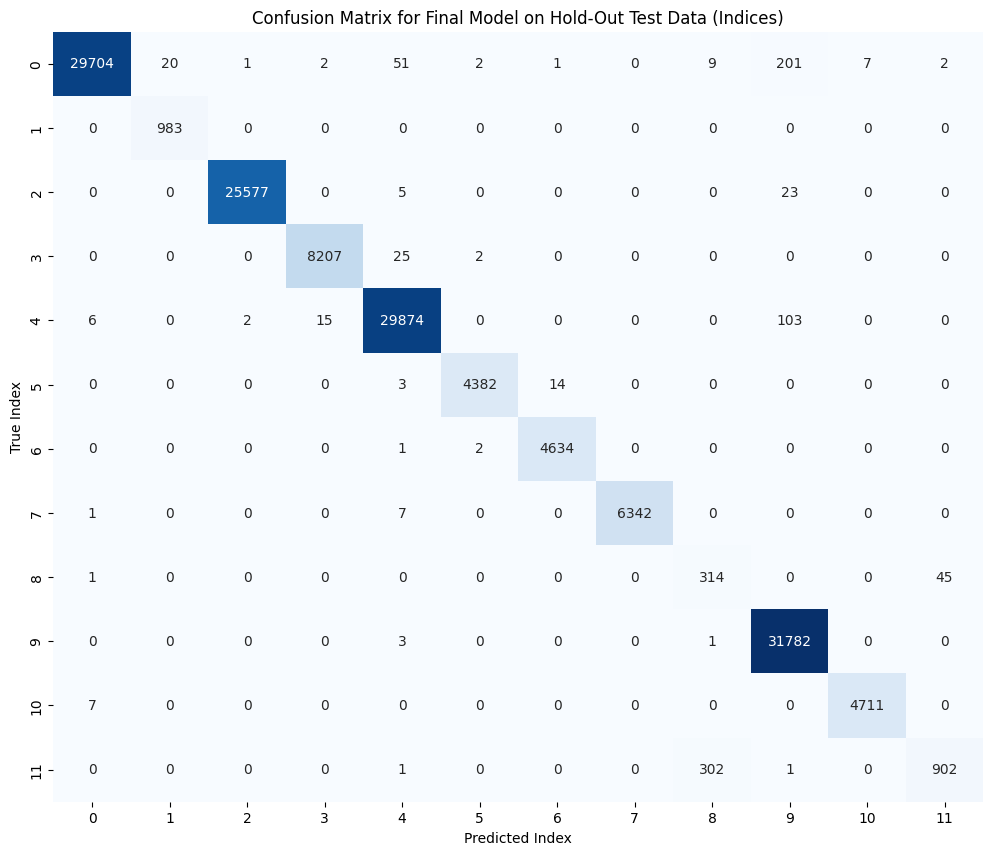

In [22]:
print("Final prediction on the train set:")
y_pred = final_tuned_lgbm.predict(X)

labels = np.unique(y)

print("\n=======================================================")
print("🏆 FINAL CLASSIFICATION REPORT (Generalization Test)")
print("=======================================================")
print(classification_report(
    y,
    y_pred,
    labels=labels,
    zero_division=0
))
print("=======================================================")

final_f1_macro = f1_score(y, y_pred, average='macro', zero_division=0)
print(f"Final Macro F1-Score on Test Set: {final_f1_macro:.4f}")

cm = confusion_matrix(y, y_pred, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=labels,
    yticklabels=labels
)
plt.title('Confusion Matrix for Final Model on Hold-Out Test Data (Indices)')
plt.xlabel('Predicted Index')
plt.ylabel('True Index')
plt.show()

Starting prediction on the hold-out test set...

🏆 FINAL CLASSIFICATION REPORT (Generalization Test)
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6000
           1       0.98      1.00      0.99      1966
           2       1.00      1.00      1.00      6000
           3       1.00      1.00      1.00      2059
           4       1.00      1.00      1.00      6000
           5       0.99      1.00      1.00      1100
           6       1.00      0.99      1.00      1159
           7       1.00      1.00      1.00      1588
           8       0.66      0.57      0.61       360
           9       0.99      1.00      1.00      6000
          10       1.00      1.00      1.00      1179
          11       0.59      0.66      0.62       301

    accuracy                           0.99     33712
   macro avg       0.93      0.93      0.93     33712
weighted avg       0.99      0.99      0.99     33712

Final Macro F1-Score on Test Set

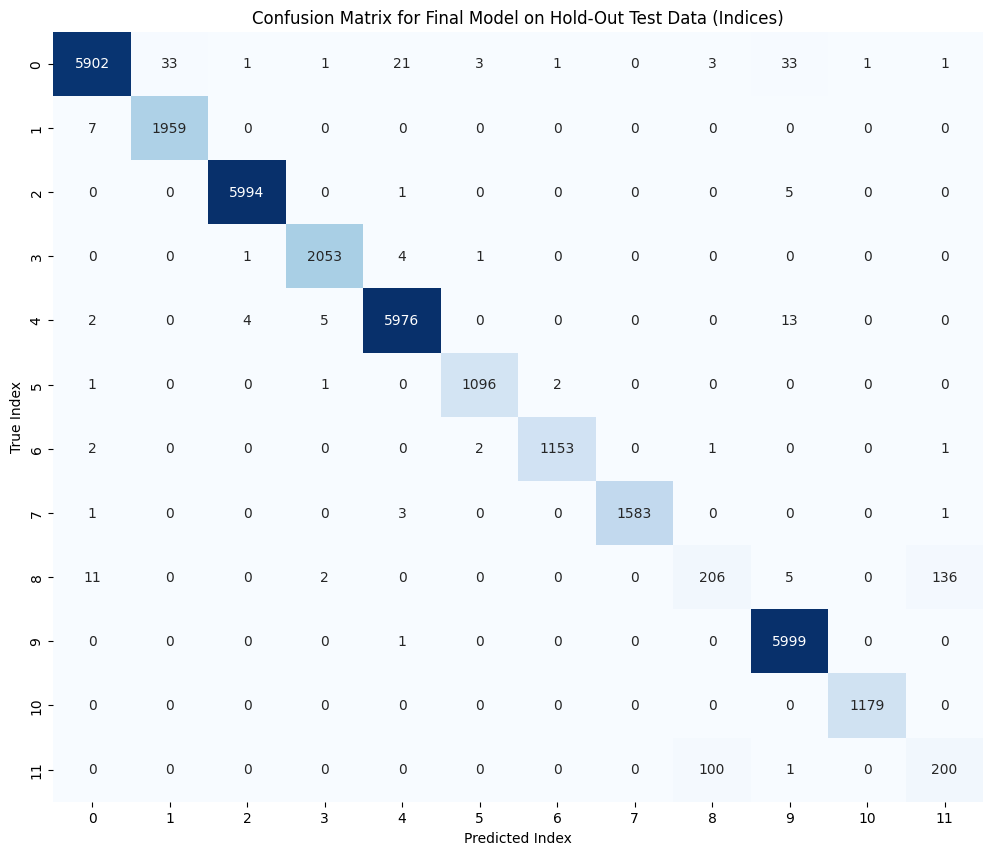

In [23]:


print("Starting prediction on the hold-out test set...")
y_pred_encoded = final_tuned_lgbm.predict(X_test)



labels = np.unique(y_test)

print("\n=======================================================")
print("🏆 FINAL CLASSIFICATION REPORT (Generalization Test)")
print("=======================================================")
print(classification_report(
    y_test,
    y_pred_encoded,
    labels=labels,
    zero_division=0
))
print("=======================================================")


final_f1_macro = f1_score(y_test, y_pred_encoded, average='macro', zero_division=0)
print(f"Final Macro F1-Score on Test Set: {final_f1_macro:.4f}")


cm = confusion_matrix(y_test, y_pred_encoded, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=labels, 
    yticklabels=labels
)
plt.title('Confusion Matrix for Final Model on Hold-Out Test Data (Indices)')
plt.xlabel('Predicted Index')
plt.ylabel('True Index')
plt.show()

In [24]:
import joblib
joblib.dump(final_tuned_lgbm,"models/lightgbm_model2.joblib")

['models/lightgbm_model2.joblib']